<a href="https://colab.research.google.com/github/Jordy-Castillo/FC_Jordy-Castillo-Trabajos/blob/main/FC_Taller02_JordyCastillo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Jordy-Castillo/FC_Jordy-Castillo-Trabajos/blob/main/Taller02/FC_Taller02_JordyCastillo.ipynb)

# **FISICA COMPUTACIONAL - TALLER #2**
* **Tema:** Estructuras de Control, Ciclos y Condicionales $C^3$
* **Lenguaje:** Python
* **Estudiante:** Jordy Castillo Jordán
* **Fecha:** 24/09/2026



# **PARTE A:**




--------------------------------------------------------------------------
**1) Complete y depure suma_seno (sección 7, "B. Completar el algoritmo") si aún no lo ha hecho.**

In [13]:
#COPIAMOS EL ALGORITMO PLANTEADO EN LA PRESENTACIÓN

#Recordemos el criterio mixto dado: |tn|<tol max(1, |Sn|) el condiciona if

def suma_seno(x, tol=1e-8, max_iter=200):            # Define una función para aproximar sin(x) mediante su serie de Taylor.
    term = x                                         # Inicializa el primer término de la serie: t_0 = x.
    total = x                                        # Inicializa la suma parcial con el primer término.
    n = 0                                            # Inicializa el índice usado para construir los términos siguientes.

    for i in range(max_iter):                        # Repite como máximo max_iter veces para evitar un ciclo infinito.
        n += 1                                       # Incrementa n antes de calcular el siguiente término de la serie.
        term = -term * (x**2) / ((2*n)*(2*n +1))     # COMPLETAR: usa la relación recursiva para calcular el nuevo término a partir del anterior.
        total = total + term                         # Añade el nuevo término a la suma parcial.

        if abs(term)<tol*max(1, abs(total)):         # COMPLETAR: escribe el criterio de parada mixto basado en term, tol y total.
            break                                    # Sale del ciclo cuando el último término ya es suficientemente pequeño.

    return total, i + 1                              # Devuelve la aproximación calculada y el número de iteraciones realizadas.

--------------------------------------------------------------------------
**2) Genere la tabla de convergencia (como en la sección 7) para al menos 6 valores de entre y , incluyendo el número de iteraciones, la suma y el error relativo frente a math.sin.**

In [56]:
#importamos librerias que necesitaremos en este paso y en posteriores
import math

#aplicamos el algoritmo planteado en las presentaciones, teniendo en cuenta que el rango es [0, 4pi]
#en mi caso, elegiré 16 valores en lugar de 13 para evaluar X

print(f"{'x':>5}  {'IMAX':>7} {'SUMA DEL SENO':>16}  {'ERROR RELATIVO':>16}")  # Imprime el encabezado de una tabla con columnas alineadas.
for x in [0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0]:  # Recorre varios valores de x para probar el algoritmo. (ELEGIDOS)
    approx, iters = suma_seno(x)                             # Calcula la aproximación de sin(x) y guarda también las iteraciones utilizadas.
    exacto = math.sin(x)                                     # Calcula el valor de referencia usando la implementación de math.sin.
    error_relativo = abs(approx - exacto) / abs(exacto)                     # Calcula el error relativo de la aproximación respecto al valor de referencia.
    print(f"{x:6.2f} {iters:6d} {approx:16.10f} {error_relativo:16.2e}")    # Imprime una fila de la tabla con formato numérico.


    x     IMAX    SUMA DEL SENO    ERROR RELATIVO
  0.50      4     0.4794255386         2.55e-11
  1.00      6     0.8414709848         9.05e-13
  2.00      8     0.9092974268         4.70e-12
  3.00      9     0.1411200079         1.43e-09
  4.00     11    -0.7568024954         9.38e-11
  5.00     13    -0.9589242747         2.14e-11
  6.00     14    -0.2794154980         5.58e-10
  7.00     16     0.6569865988         5.38e-11
  8.00     17     0.9893582464         1.83e-10
  9.00     19     0.4121184852         9.24e-11
 10.00     20    -0.5440211107         2.89e-10
 11.00     21    -0.9999902071         5.77e-10
 12.00     23    -0.5365729181         2.21e-10


--------------------------------------------------------------------------
**3) Con los datos de la tabla del punto anterior, compare el error relativo de cada caso contra la tolerancia esperada $10^{-8}$: ¿en todos los valores de $x$ que probó el error relativo queda por debajo de esa tolerancia? Si en algún caso no es así, indique para cuáles valores de $x$ ocurre y explique a qué se debe.**

Al analizar los valores del error relativo para (x), podemos concluir que todos los valores quedan por debajo de la tolerancia de $10^{-8}$. Los errores relativos obtenidos varian entre $10^{-13}$ y $10^{-9}$, los cuales son mucho menores que la tolerancia establecida de $10^{-8}$.

--------------------------------------------------------------------------
**4. Repita el experimento de la sección 7 para $x$ grande (por ejemplo, $x=100$) **sin** la reducción de periodicidad, y explique en una o dos frases qué está pasando numéricamente.**

In [119]:
#copiamos el algortimo del punto 2, pero quitando el ciclo for ya que solo evaluaremos 1 valor de x
#de esta forma, podemos visualizarlo en forma de tabla para mejor presentacion

x_grande= 100    #definimos el valor de x=100

print(f"{'x':>4} {'IMAX':>8} {'SUMA DEL SENO':>28} {"Exacto":>27}  {'ERROR RELATIVO':>23}")    #Imprimimos el encabezado de una tabla

approx, iters = suma_seno(x_grande)                    # Calcula la aproximación de sin(x)
exacto = math.sin(x_grande)                            # Calcula el valor de referencia usando la implementación de math.sin.
error_relativo = abs(approx - exacto) / abs(exacto)    # Calcula el error relativo de la aproximación respecto al valor de referencia.

print(f"{x_grande:4.2f} {iters:6d}    {approx:16.10f}  {exacto:16.10f}   {error_relativo:16.2e}")   #imprimir resultados en posciones de la tabla

   x     IMAX                SUMA DEL SENO                      Exacto           ERROR RELATIVO
100.00    111    -82613756717171637724643328.0000000000     -0.5063656411           1.63e+26


Al evaluar la serie de Tylor para x=100, los terminos de la suma del seno alcanzan magnitudes enormes, sobrepasando la capacidad del programa y del formato IEEE 754, debido al hecho de que sumar y restor numeros tan grandes, genera una cancelacion masiva, destruyendo digitos significativos. Esto desarrolla que dicha suma adquiera valores grandes absurdos y que el error relativo tambien sea exageradamente grande.

* Dato adicional: Intenté evaluar (x) con valores de 200, 300, 400 y 500, y el resultado presentado destruye la tabla por completo al tener demasiadas cifras en la suma de senos.

--------------------------------------------------------------------------
**5. Compare su implementación recursiva con una versión "ingenua" que calcule cada término desde cero usando `math.factorial` y `x**potencia` — ¿en qué valores de $x$ empieza a notarse la diferencia de desempeño o de precisión?**

In [141]:
#definimos una funcion ingenua para calcular termino a termino de manera lenta, siguiendo un poco los puntos anteriores

def suma_seno_ingenua(x, tol=1e-8, max_iter=200):                         #mantenemos las condiciones de la funcion igual que antes

    total = 0.0                                                           #un acumulador de la suma de forma inicial
    for n in range(max_iter):
        parentesis = 2 * n + 1                                            #definimos la expresion de la serie, 2n+1
        term = ((-1)**n) * (x**parentesis) / math.factorial(parentesis)   #aplicamos la formula de la serie de taylor
        total += term                                                     #añadimos el nuevo termino a la suma

        if abs(term) < tol * max(1.0, abs(total)):                        #definimos un criterio de parada segun la tolerancia
            break

    return total, n + 1                                                   #nos devuelve la suma

#realizamos la comparacion, definiendo unos valores de prueba
valores_prueba = [1.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0]

print(f"{'x':>6}  {'Recursiva (Aprox)':>24}  {'Ingenua (Aprox)':>20}  {'Diferencia/Error':>22}")   #encabezado de la tabla bonita

#creamos un ciclo para comparar los valores y su error/diferencia
for x in valores_prueba:
    try:                                                   #usamos par que un NotImplementedError detenga toda la celda
        recursiva_val, _ = suma_seno(x)
        ingenua_val, _ = suma_seno_ingenua(x)
        dif = abs(recursiva_val - ingenua_val)

        print(f"{x:6.1f}  {recursiva_val:22.10e}  {ingenua_val:20.10e}  {dif:19.2e}")              #colocar valores en la tabla

    except OverflowError:          #usamos except para identificar si hay un desborde, si sucede, lo digita en la tabla en vez de generar error
        print(f"{x:6.1f}  {recursiva_val:20.10e}  {'OverflowError (desborde)':>20}  {'N/A':>18}")  #colocar valores en la tabla

     x         Recursiva (Aprox)       Ingenua (Aprox)        Diferencia/Error
   1.0        8.4147098481e-01      8.4147098481e-01             0.00e+00
   5.0       -9.5892427468e-01     -9.5892427468e-01             4.33e-15
  10.0       -5.4402111073e-01     -5.4402111073e-01             4.86e-13
  15.0        6.5028783993e-01      6.5028783990e-01             3.20e-11
  20.0        9.1294525561e-01      9.1294524781e-01             7.80e-09
  25.0       -1.3235169730e-01     -1.3235144187e-01             2.55e-07
  30.0       -9.8807342546e-01     -9.8799985732e-01             7.36e-05
  35.0       -4.2414003438e-01     -4.1964440575e-01             4.50e-03
  40.0        2.0504069059e+00     -2.0578501349e-01             2.26e+00
  45.0        1.3393453528e+02     -3.0299510356e+02             4.37e+02
  50.0       -1.5566595934e+04      2.7473524085e+04             4.30e+04


Al analizar los resultados de la tabla, lo primero que notamos es que ninguno de los valores elegidos de (x) presentó un OverflowError. Vemos como a medidad que aumenta el valor de (x), la diferencia entre ambos metodos se hace mucho mas grande, aumentando en ordenes de $10^{2}$. No se puede decir que haya un valor (x) especifico en donde se note dicho incremento de la diferencia, ya que desde el segundo valor (x=5) se empieza a disminuir proporcionalmente.

# **PARTE B:**
Durante la semana anterior estudiamos el **decaimiento radiactivo utilizando FORTRAN**. En este ejercicio retomaremos el mismo sistema físico, pero utilizaremos Python para trabajar con un conjunto de valores, analizar los resultados y representarlos gráficamente.

El número de núcleos radiactivos presentes en una muestra evoluciona de acuerdo con

$$
N(t)=N_0e^{-\lambda t},
$$

donde $N_0$ es el número inicial de núcleos y $\lambda$ es la constante de decaimiento. Esta constante se relaciona con la vida media $t_{1/2}$ mediante

$$
\lambda=\frac{\ln(2)}{t_{1/2}}.
$$

Considere una muestra con

$$
N_0=10\,000
$$

núcleos radiactivos y una vida media de

$$
t_{1/2}=5\ \mathrm{años}.
$$



**1. Calcule la constante de decaimiento $\lambda$.**

In [158]:
#para esta parte B, importaremos librerias que usaremos
import numpy as np
import matplotlib.pyplot as plt

#definimos el tiempo de vida media
tmedia= 5

#realizamos la ecuacion para hallar lambda
lambdaa= np.log(2.0)/tmedia

#imprimimos el resultado, pero limitandolo a 2 decimales unicamente para mayor comodidad
print("La constante de decaimiento (lambda) es: ", f"{lambdaa:.2f}")



La constante de decaimiento (lambda) es:  0.14


**2. Utilice `numpy.linspace()` para crear un arreglo de tiempos entre **0 y 30 años**. Utilice un número suficiente de puntos para observar claramente la evolución de la muestra.**

In [164]:
#definimos el arreglo de tiempo, que inicia de 0 a 30, con 150 intervalos (o puntos)
t= np.linspace(0, 30, 150)

#no usamos print debido a que el arreglo es muy grande para visualizarlo de forma presentable

**3. Calcule $N(t)$ para todos los valores del arreglo de tiempos utilizando las operaciones vectorizadas de NumPy.**

In [167]:
#definimos el N0 dado
N0=10000

#aplicamos la formula dada de N(t), en donde mezclaremos el valor de lambda hallado y el arreglo de tiempos
Nt= N0*np.exp(-lambdaa*t)

#no usamos print debido a que el arreglo es muy grande para visualizarlo de forma presentable

**4. Utilice `matplotlib` para representar gráficamente $N(t)$ en función del tiempo. La gráfica debe incluir:**

   - título;
   - nombre de los ejes;
   - unidades;
   - una cuadrícula que facilite la lectura de los resultados.

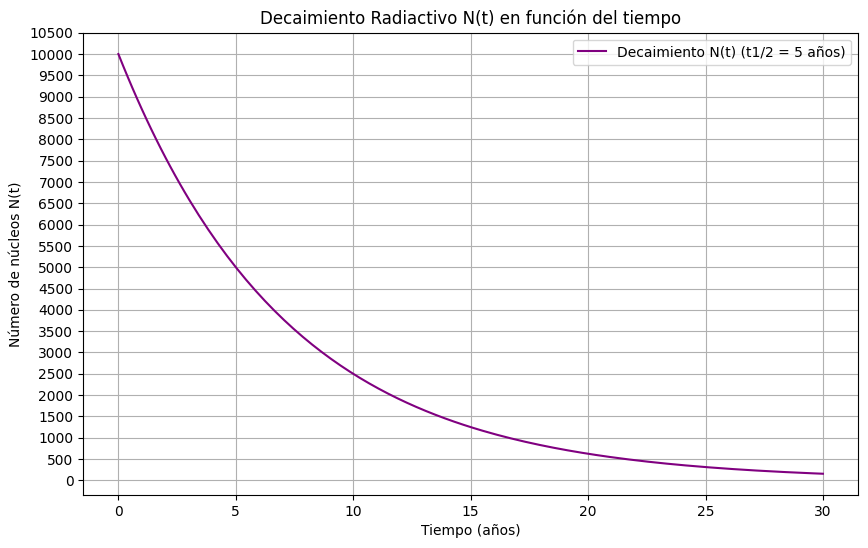

In [198]:
#como ya tenemos las variables que necesitamos definidas anteriormente
#Realizamos la gráfica ajustando un tamaño
plt.figure(figsize=(10,6))

#Graficamos la curva N(t) en función de (t) para la vida media dada al prinicipio (5 años)
plt.plot(t, Nt, label=f"Decaimiento N(t) (t1/2 = 5 años)", color="purple")
plt.title("Decaimiento Radiactivo N(t) en función del tiempo")
plt.xlabel("Tiempo (años)")
plt.ylabel("Número de núcleos N(t)")
plt.xticks(np.arange(0, 31, 5))
plt.yticks(np.arange(0, 11000, 500))
plt.grid()
plt.legend()
plt.show()

**5. Identifique sobre la gráfica los tiempos correspondientes a **una, dos y tres vidas medias**. Observe qué fracción de la muestra permanece después de cada una de ellas.**

Después de 5 años (1 vida media): 5000 núcleos -- Fraccion: (1/2)
Después de 10 años (2 vidas medias): 2500 núcleos -- Fraccion: (1/4)
Después de 15 años (3 vidas medias): 1250 núcleos -- Fraccion: (1/8)


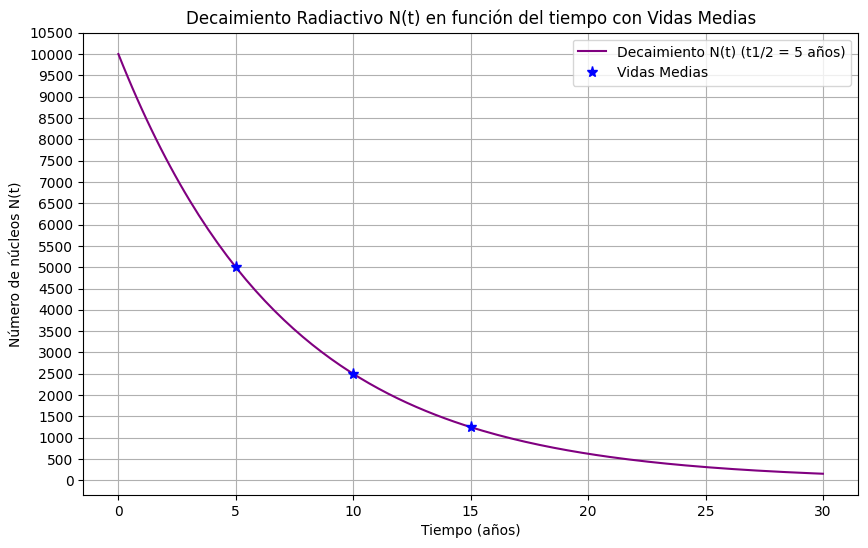

In [254]:
# identificamos los puntos de vida media (tmedia = 5 años, los cuales son 5,10 y 15, ya que van en multiplos de 5)
t_vidas = np.array([5,10,15])

#Calculamos el número de N(t) en cada punto de vida media
N_vidas = N0 * np.exp(-lambdaa * t_vidas)

#imprimimos los valores de cada punto de vida media para mejor visualización al compilar
#asi mismo, en este paso calculamos la fraccion de muestra que permanece despues de esos tiempos, mediante N0 / Nvidas (valor inicial / tvida)
print(f"Después de {t_vidas[0]:.0f} años (1 vida media): {N_vidas[0]:.0f} núcleos -- Fraccion: (1/{N0/N_vidas[0]:.0f})")
print(f"Después de {t_vidas[1]:.0f} años (2 vidas medias): {N_vidas[1]:.0f} núcleos -- Fraccion: (1/{N0/N_vidas[1]:.0f})")
print(f"Después de {t_vidas[2]:.0f} años (3 vidas medias): {N_vidas[2]:.0f} núcleos -- Fraccion: (1/{N0/N_vidas[2]:.0f})")

#copiamos y pegamos lo del punto anterior para elaborar la grafica de la misma forma
plt.figure(figsize=(10,6))
plt.plot(t, Nt, label=f"Decaimiento N(t) (t1/2 = 5 años)", color="purple")
plt.plot(t_vidas, N_vidas, 'b*', markersize=8, label="Vidas Medias")  #Marcamos los puntos de las vidas medias en la curva
plt.title("Decaimiento Radiactivo N(t) en función del tiempo con Vidas Medias")
plt.xlabel("Tiempo (años)")
plt.ylabel("Número de núcleos N(t)")
plt.xticks(np.arange(0, 31, 5))
plt.yticks(np.arange(0, 11000, 500))
plt.grid()
plt.legend()
plt.show()

**6. Determine aproximadamente el tiempo en el cual permanece:**

   - el **50 %** de la muestra inicial;
   - el **25 %** de la muestra inicial;
   - el **10 %** de la muestra inicial.

Primero, hay que despejar t de la ecuación original.Esto lo hacemos aplicando logaritmo a ambos lados. Luego despejamos t normalmente, ya que se elimina la exponencial. Nos da:

$t = \frac{\ln\left(\frac{N_0}{N(t)}\right)}{\lambda}$

Por lo cual, la fracción $\frac{N_0}{N(t)}$, al ser el cociente entre el total de núcleos y los núcleos en función del tiempo, podemos ver que dicho cociente corresponde a la fracción que debería tener de la muestra inicial al pasar t años. Y como los porcentajes pueden ser expresados en fracciones, o mejor dicho, de forma decimal, podemos concluir que el término dentro del logaritmo será nuestro porcentaje que nos piden. De esta forma, al evaluar en la ecuación despejada, tendremos los valores del tiempo que corresponden a dicho porcentaje de la muestra inicial.

In [265]:
#definimos nuestra lista de porcentajes N0/N(t)
porcentajes = [0.50, 0.25, 0.10]

#aplicamos un ciclo for para no tener que calcular uno por uno
for porc in porcentajes:
    t_calculado = -np.log(porc) / lambdaa     #aplicar ecuacion despejada
    nucleos = N0 * porc                       #calcular N(t) de cada tiempo (despejar N(t) de nuestro cociente antes asimilado)

    print(f"Se conserva {porc*100}% ({nucleos:.0f} núcleos): t ≈ {t_calculado:2.2f} años")

Se conserva 50.0% (5000 núcleos): t ≈ 5.00 años
Se conserva 25.0% (2500 núcleos): t ≈ 10.00 años
Se conserva 10.0% (1000 núcleos): t ≈ 16.61 años


# **PARTE C:**

Para agilizar la revisión, la tarea debe cerrar con una celda que compruebe automáticamente 2-3 casos conocidos e imprima PASS/FAIL — no hace falta rastrear la lógica a mano para calificar. Abajo hay una celda de verificación para la Parte A (usa `suma_seno_reducida`, ya definida en la sección 7) y una plantilla para la Parte B: complete `N_decaimiento` con $N(t) = N_0 e^{-\lambda t}$ y la celda le dirá si sus resultados coinciden con los valores esperados (recordando el caso de la vida media del carbono-14 de la Semana 1: al cabo de una vida media siempre queda el 50 % de la muestra).


In [273]:
# --- Verificación Parte A: suma_seno ---
casos_a = [                                        # Lista de (x, valor_esperado, tolerancia) para probar la Parte A.
    (0.5, math.sin(0.5), 1e-8),                    # Caso dentro del rango normal de convergencia rápida.
    (100.0, math.sin(100.0), 1e-6),                # Caso con x grande: solo debe pasar si se usó reducción de argumento.
    (-237.0, math.sin(-237.0), 1e-6),              # Caso con x grande y negativo.
]

for x, esperado, tol in casos_a:                   # Recorre cada caso de prueba uno por uno.
    obtenido, _ = suma_seno(x)                     # Calcula sin(x) con tu función personalizada.
    ok = abs(obtenido - esperado) < tol             # Compara contra el valor de referencia dentro de la tolerancia.
    estado = "PASS" if ok else "FAIL"               # Traduce el resultado booleano a texto legible.
    print(f"{estado}  x={x:>8.1f}   obtenido={obtenido: .10f}   esperado={esperado: .10f}")  # Imprime el veredicto de este caso.

PASS  x=     0.5   obtenido= 0.4794255386   esperado= 0.4794255386
FAIL  x=   100.0   obtenido=-82613756717171637724643328.0000000000   esperado=-0.5063656411
FAIL  x=  -237.0   obtenido=-42614211402367315859734446500583751908998943685789299717352743442888170896200929640448.0000000000   esperado= 0.9819578698


Al evaluar la serie de Tylor para el seno con valores grandes, como x=100 y x=-237, sin reducir el argumento (como exige el ejercicio 4), el algoritmo falla debido a esa cancelacion masiva. Asimismo, como limitamos un dominio (-$\pi$ a $\pi$), los terminos de la ecuacion crecen exponencialmente antes de empeza a decrecer. Es por ello que para esos dos valores, la prueba marca FAIL

In [274]:
# --- Parte B: N_decaimiento completada y verificación ---
def N_decaimiento(t, N0=10000, t_half=5.0):        #funcion completada según N(t) = N0 * exp(-lambda*t).
    lambdaa = np.log(2.0) / t_half                # Constante de decaimiento
    return N0 * np.exp(-lambdaa * t)

casos_b = [                                        # Lista de (t, fracción_esperada): fracción de N0 que debería quedar en cada instante.
    (0.0, 1.00),                                   # En t=0 debe quedar el 100% de la muestra.
    (5.0, 0.50),                                   # En t = t_1/2 (una vida media) debe quedar el 50%.
    (10.0, 0.25),                                  # En t = 2*t_1/2 (dos vidas medias) debe quedar el 25%.
]

for t, fraccion_esperada in casos_b:               # Recorre cada caso de prueba.
    try:                                           # Evita que un NotImplementedError detenga toda la celda de verificación.
        obtenido = N_decaimiento(t) / 10000        # Calcula qué fracción de N0 queda en el instante t.
        ok = abs(obtenido - fraccion_esperada) < 1e-3  # Compara contra la fracción esperada con tolerancia razonable.
        estado = "PASS" if ok else "FAIL"
        print(f"{estado}  t={t:>5.1f} años   fraccion={obtenido:.3f}   esperada={fraccion_esperada:.3f}")
    except NotImplementedError as e:               # Si aún no se ha completado la función, lo informa sin detener la celda.
        print(f"FAIL  t={t:>5.1f} años   ({e})")

PASS  t=  0.0 años   fraccion=1.000   esperada=1.000
PASS  t=  5.0 años   fraccion=0.500   esperada=0.500
PASS  t= 10.0 años   fraccion=0.250   esperada=0.250


Los 3 casos pasan efectivamente con un PASS, lo que indica que el algortimo desarrolado es exitoso.